# Regression Feature Merging

> **Scope.** This notebook only **merges the household-value regression into the classification dataset as features**. It does not train or tune anything, neither the regression nor the classifier, it does not score any data set, and it does not change the classification team's notebooks or their `model_state.csv`. The result is a **new** file, `model_state_with_reg.csv`, which is `model_state.csv` plus five columns.

## Inputs

| file | folder | use |
|---|---|---|
| `model_state.csv` | `data/processed/` | the 431 classification states (key = `Property_ID` and `Prediction_Time`), read only |
| `myVal_Synthetic_Datasets_release_v2.xlsx` | `data/raw/` | the `assets` and `properties` sheets. The documented value is recalculated **without vehicles** in the same way as `02_fm_target_definition` builds `documented_value_total` (the sum of `Current_Estimated_Value` of the assets with `Created_At <= Prediction_Time`), and the items of each basket are taken from the same sheet |
| `regression_predictions_all_splits.csv` | `data/processed/regression/` | the predictions of the simulated baskets from `07_ky_prediction_table`. It is used **only as a check** that the saved models and the blend weight are the ones that produced it. It cannot be joined to the states, because it has no `Prediction_Time` and its baskets are random draws from the whole inventory, so they contain items that were documented after the state time |
| `ensemble_weight_and_margins.csv` | `models/regression/` | the blend weight (XGBoost 0.28 and LightGBM 0.72) |
| `val_df.parquet` | `data/processed/regression/` | the validation baskets used for the model check |
| `xgb_log_model.joblib`, `lgbm_log_model.joblib` | `models/regression/` | the two regression models, fitted on `log1p` of the household total in `03_ky_modelling_xgboost_lightgbm`. They are **loaded and never refitted** |

The train, validation and test label of every state is rebuilt from `model_state.csv` with the code of `03_fm_modelling` and is used only for the diagnostics file.

## Outputs

- `data/processed/classification/model_state_with_reg.csv`: This is `model_state.csv` plus the five columns below, and all original columns stay unchanged.
- `data/interim/regression/regression_state_diagnostics.csv`: This file has one row per state with the intermediate values (the basket used, the raw predictions, the split, the in-sample flag and the vehicle value). It is **not** a model input.

## The five new columns

| column | meaning | when `reg_available = 0` |
|---|---|---|
| `documented_value_nv` | the value documented at `Prediction_Time` for **non-vehicle** items with a value (`nv` stands for non-vehicle) | always filled and never padded |
| `reg_pred_total_nv` | the regression prediction of the total non-vehicle contents value of the household, never below `documented_value_nv` | -1 |
| `reg_pred_gap_nv` | `reg_pred_total_nv - documented_value_nv`, which is the estimated value not yet documented | -1 |
| `reg_completeness_nv` | `documented_value_nv / reg_pred_total_nv` (between 0 and 1), which shows how much of the household is documented | -1 |
| `reg_available` | 1 if at least 10 non-vehicle items with a value are documented at `Prediction_Time`, otherwise 0 | 0 |

The `reg_` prefix marks the columns that come from the regression, so they can be dropped in one line, like the `ai_` columns. The value `-1` is a sentinel outside the real range. It is filled **here**, so that the median imputer of the classifier does not invent values for the states that have no regression estimate.

## Names used in this notebook

| name | full name | meaning | where it is saved |
|---|---|---|---|
| `nv` | non-vehicle | suffix for values that exclude vehicles | in the column names `documented_value_nv`, `reg_pred_total_nv`, `reg_pred_gap_nv` and `reg_completeness_nv` |
| `n_nv` | number of non-vehicle items | how many non-vehicle items **with a value** are documented at `Prediction_Time` (`Created_At <= Prediction_Time`, `Category` is not `Vehicles` and `Current_Estimated_Value` is not missing). It decides `reg_available` (`n_nv >= 10`) and the checkpoint | **not** a column of `model_state_with_reg.csv`, and kept in the diagnostics file |
| `checkpoint` | basket size | `n_nv` rounded down to 10, 20, 30 or 50, where 0 means fewer than 10 items and no regression estimate | diagnostics file |
| `reg_` | regression | prefix of the columns that come from the regression models | in the column names |
| `vehicle_value_recorded` | recorded vehicle value | the value of the vehicles documented by `Prediction_Time` | diagnostics file |

## Rules used

1. **Only items documented by the state time:** An item counts only if `Created_At <= Prediction_Time`.
2. **Basket = the earliest N items by `Created_At`** (ties broken by `Asset_ID`), with N equal to the checkpoint: 10 for 10 to 19 documented items, 20 for 20 to 29, 30 for 30 to 49 and 50 for 50 or more. A home with 19 items still uses the earliest 10, and at 20 items the earliest 20 are used. There are no random draws. The documented value always uses **all** documented items, so `reg_pred_total_nv` is the same for every state of one checkpoint, while `reg_pred_gap_nv` and `reg_completeness_nv` move with each new item.
3. **Vehicles never enter the regression:** They are not in the basket, not in the prediction and not in `documented_value_nv`. The classification team's `documented_value_total`, which includes vehicles, is left as it is.
4. **No training and no scoring:** The models only predict.

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

# -------------------------------------------------------------------
# Files
# -------------------------------------------------------------------

ROOT = Path("../..")

RAW_XLSX = ROOT / "data/raw/myVal_Synthetic_Datasets_release_v2.xlsx"
STATE_FILE = ROOT / "data/processed/model_state.csv"
REG_CSV = ROOT / "data/processed/regression/regression_predictions_all_splits.csv"      # written by 07_ky_prediction_table
WEIGHT_FILE = ROOT / "models/regression/ensemble_weight_and_margins.csv"
CHECK_FILE = ROOT / "data/processed/regression/val_df.parquet"
MODEL_DIR = ROOT / "models/regression"

OUT_FINAL = ROOT / "data/processed/classification/model_state_with_reg.csv"
OUT_DIAG = ROOT / "data/interim/regression/regression_state_diagnostics.csv"

for path in [RAW_XLSX, STATE_FILE, REG_CSV, WEIGHT_FILE, CHECK_FILE,
             MODEL_DIR / "xgb_log_model.joblib", MODEL_DIR / "lgbm_log_model.joblib"]:
    if not path.exists():
        raise FileNotFoundError(f"Missing input: {path}")

print("All input files found.")

All input files found.


## Load the Data

`model_state.csv` is read exactly as saved. The numbers are read with `float_precision="round_trip"`, so every value is the same number as in the file, and the `Prediction_Time` text is kept as it is for the output file. A parsed copy of the time is used for the time comparisons. The `assets` and `properties` sheets are read from the raw workbook in the same way as `02_fm_target_definition` reads them.

In [2]:
model_state = pd.read_csv(STATE_FILE, float_precision="round_trip")
state_time = pd.to_datetime(model_state["Prediction_Time"])
ORIGINAL_COLUMNS = list(model_state.columns)

assets = pd.read_excel(RAW_XLSX, sheet_name="assets")
properties = pd.read_excel(RAW_XLSX, sheet_name="properties")
assets["Created_At"] = pd.to_datetime(assets["Created_At"], errors="coerce")

print(f"States:     {len(model_state):,} ({model_state['Property_ID'].nunique():,} properties, {model_state.shape[1]} columns)")
print(f"Assets:     {len(assets):,}   (missing timestamps: {assets['Created_At'].isna().sum()})")
print(f"Properties: {len(properties):,}")

assert not model_state.duplicated(subset=["Property_ID", "Prediction_Time"]).any()
assert assets["Created_At"].notna().all()

# the household context columns already in model_state must equal the properties sheet
ctx = model_state[["Property_ID", "Property_Type", "Occupancy_Type", "Number_Of_Occupants", "Number_Of_Bedrooms", "Property_Valuation_AUD"]].merge(
    properties[["Property_ID", "Property_Type", "Occupancy_Type", "Number_Of_Occupants", "Number_Of_Bedrooms", "Property_Valuation_AUD"]],
    on="Property_ID", how="left", suffixes=("", "_sheet"))
for c in ["Property_Type", "Occupancy_Type", "Number_Of_Occupants", "Number_Of_Bedrooms", "Property_Valuation_AUD"]:
    assert (ctx[c].values == ctx[c + "_sheet"].values).all(), c
print("Household context in model_state equals the properties sheet.")

States:     431 (234 properties, 60 columns)
Assets:     8,309   (missing timestamps: 0)
Properties: 795
Household context in model_state equals the properties sheet.


## Documented Value Without Vehicles

For every state, the assets documented **at or before** `Prediction_Time` are collected exactly as in `02_fm_target_definition` (`Created_At <= Prediction_Time`). First the classification team's own numbers are reproduced with all assets, vehicles included, to prove that the extraction is the same. Then the same assets are split into non-vehicle items with a value and recorded vehicles. The value of the first group is `documented_value_nv`, and its number of items is `n_nv`, which decides `reg_available`.

In [3]:
keys = model_state[["Property_ID", "Prediction_Time"]].copy()
keys["_time"] = state_time.values

history = keys.merge(
    assets[["Property_ID", "Asset_ID", "Category", "Current_Estimated_Value", "Created_At"]],
    on="Property_ID", how="left",
)
history = history[history["Created_At"] <= history["_time"]].copy()
group_keys = ["Property_ID", "Prediction_Time"]

# 1. reproduce the classification team's documented_asset_count and documented_value_total (vehicles included)
everything = history.groupby(group_keys).agg(
    all_assets=("Asset_ID", "nunique"),
    all_value=("Current_Estimated_Value", "sum"),
).reset_index()
check = model_state[group_keys + ["documented_asset_count", "documented_value_total"]].merge(everything, on=group_keys, how="left")
assert (check["all_assets"] == check["documented_asset_count"]).all()
assert np.allclose(check["all_value"], check["documented_value_total"])
print(f"Reproduced documented_asset_count and documented_value_total for {len(check):,} of {len(model_state):,} states.")

# 2. the same assets without vehicles (and only items that have a value)
is_vehicle = history["Category"] == "Vehicles"
has_value = history["Current_Estimated_Value"].notna()

non_vehicle = history[~is_vehicle & has_value].groupby(group_keys).agg(
    n_nv=("Asset_ID", "nunique"),
    documented_value_nv=("Current_Estimated_Value", "sum"),
).reset_index()
vehicles = history[is_vehicle & has_value].groupby(group_keys).agg(
    vehicle_value_recorded=("Current_Estimated_Value", "sum"),
).reset_index()

state_values = (
    model_state[group_keys + ["documented_value_total"]]
    .merge(non_vehicle, on=group_keys, how="left")
    .merge(vehicles, on=group_keys, how="left")
    .fillna({"n_nv": 0, "documented_value_nv": 0.0, "vehicle_value_recorded": 0.0})
)
state_values["n_nv"] = state_values["n_nv"].astype(int)

# documented_value_total (their column) = non-vehicle value + vehicle value
assert np.allclose(state_values["documented_value_nv"] + state_values["vehicle_value_recorded"], state_values["documented_value_total"])

# checkpoint: floor to 10 / 20 / 30 / 50 (0 = fewer than 10 items, no regression estimate)
def floor_to_checkpoint(n):
    return 50 if n >= 50 else 30 if n >= 30 else 20 if n >= 20 else 10 if n >= 10 else 0

state_values["checkpoint"] = state_values["n_nv"].map(floor_to_checkpoint)
state_values["reg_available"] = (state_values["checkpoint"] > 0).astype(int)

print(f"documented_value_nv + vehicle value equals documented_value_total in all {len(state_values):,} states.")
print(f"States with a vehicle already documented: {int((state_values['vehicle_value_recorded'] > 0).sum())}")
print(f"States with reg_available = 1 (at least 10 non-vehicle items with a value): {int(state_values['reg_available'].sum())} of {len(state_values)}")
display(state_values["checkpoint"].value_counts().sort_index().rename("states").to_frame())

Reproduced documented_asset_count and documented_value_total for 431 of 431 states.
documented_value_nv + vehicle value equals documented_value_total in all 431 states.
States with a vehicle already documented: 6
States with reg_available = 1 (at least 10 non-vehicle items with a value): 71 of 431


,states
checkpoint,
0,360
10,46
20,9
30,13
50,3


## Baskets: the Earliest N Items

For each state with `reg_available = 1` the basket is the earliest N non-vehicle items with a value, where N is the checkpoint. The same 26 feature columns as in the regression's modelling data are computed from it. They consist of summary statistics of the values, the value per category, the number of categories, the household context and the basket size. The column order is read from the saved models.

In [4]:
xgb_model = joblib.load(MODEL_DIR / "xgb_log_model.joblib")
lgbm_model = joblib.load(MODEL_DIR / "lgbm_log_model.joblib")
FEATURE_COLS = [str(c) for c in xgb_model.feature_names_in_]
assert FEATURE_COLS == [str(c) for c in lgbm_model.feature_name_]
print(f"{len(FEATURE_COLS)} regression features:", FEATURE_COLS)

weights = pd.read_csv(WEIGHT_FILE).set_index("item")["value"]
W_XGB = float(weights["blend_weight_xgboost"])
print(f"blend weight: XGBoost {W_XGB:.2f} / LightGBM {1 - W_XGB:.2f}")

# non-vehicle items with a value, in documentation order
items = (assets[(assets["Category"] != "Vehicles") & assets["Current_Estimated_Value"].notna()]
         .sort_values(["Property_ID", "Created_At", "Asset_ID"]))
items_by_property = {pid: grp for pid, grp in items.groupby("Property_ID")}
CONTENTS_CATEGORIES = sorted(assets.loc[assets["Category"] != "Vehicles", "Category"].unique())
print("contents categories:", CONTENTS_CATEGORIES)

def basket_features(basket, context):
    values = basket["Current_Estimated_Value"].to_numpy(dtype=float)
    feats = {
        "item_count": len(values), "sum_value": values.sum(), "mean_value": values.mean(), "median_value": float(np.median(values)),
        "max_value": values.max(), "min_value": values.min(), "std_value": values.std() if len(values) > 1 else 0.0,
        "n_categories_seen": basket["Category"].nunique(),
    }
    cat_sums = basket.groupby("Category")["Current_Estimated_Value"].sum()
    for cat in CONTENTS_CATEGORIES:
        name = "cat_" + cat.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_")
        feats[name] = float(cat_sums.get(cat, 0.0))
    feats["number_of_occupants"] = context["Number_Of_Occupants"]
    feats["number_of_bedrooms"] = context["Number_Of_Bedrooms"]
    feats["property_valuation_aud"] = context["Property_Valuation_AUD"]
    feats["n_documented"] = len(values)
    for col in FEATURE_COLS:
        if col.startswith("property_type_"):
            feats[col] = bool(context["Property_Type"] == col[len("property_type_"):])
        if col.startswith("occupancy_type_"):
            feats[col] = bool(context["Occupancy_Type"] == col[len("occupancy_type_"):])
    return feats

rows, basket_info = [], []
for i in state_values.index[state_values["reg_available"] == 1]:
    pid, t, c = model_state.at[i, "Property_ID"], state_time[i], int(state_values.at[i, "checkpoint"])
    documented = items_by_property[pid]
    documented = documented[documented["Created_At"] <= t]
    basket = documented.iloc[:c]
    # checks: no future item, exactly N items, N = floor of the documented count
    assert len(basket) == c and len(documented) == state_values.at[i, "n_nv"] and floor_to_checkpoint(len(documented)) == c
    assert basket["Created_At"].max() <= t
    ties = bool(len(documented) > c and documented.iloc[c - 1]["Created_At"] == documented.iloc[c]["Created_At"])
    rows.append(basket_features(basket, model_state.loc[i]))
    basket_info.append({"index": i, "basket_sum": basket["Current_Estimated_Value"].sum(), "last_basket_time": basket["Created_At"].max(), "tie_at_cut": ties})

X_states = pd.DataFrame(rows, index=[b["index"] for b in basket_info])[FEATURE_COLS]
basket_info = pd.DataFrame(basket_info).set_index("index")
print(f"Baskets built for {len(X_states)} states. No basket contains an item documented after its state, and the number of states where the cut splits items with the same timestamp is {int(basket_info['tie_at_cut'].sum())}")
display(X_states.head(3).T)

26 regression features: ['item_count', 'sum_value', 'mean_value', 'median_value', 'max_value', 'min_value', 'std_value', 'n_categories_seen', 'cat_appliances', 'cat_clothings', 'cat_electronics', 'cat_furniture', 'cat_jewellery_and_personal_items', 'cat_other_items', 'number_of_occupants', 'number_of_bedrooms', 'property_valuation_aud', 'n_documented', 'property_type_apartment', 'property_type_duplex', 'property_type_house', 'property_type_semi-detached', 'property_type_terrace', 'property_type_villa', 'occupancy_type_owner', 'occupancy_type_tenant']
blend weight: XGBoost 0.28 / LightGBM 0.72
contents categories: ['Appliances', 'Clothings', 'Electronics', 'Furniture', 'Jewellery and Personal Items', 'Other Items']


Baskets built for 71 states. No basket contains an item documented after its state, and the number of states where the cut splits items with the same timestamp is 0


,4,5,15
item_count,30,30,20
sum_value,38654.0,38654.0,17597.0
mean_value,1288.466667,1288.466667,879.85
median_value,550.0,550.0,399.0
max_value,12000.0,12000.0,6500.0
min_value,120.0,120.0,110.0
std_value,2289.45341,2289.45341,1388.747071
n_categories_seen,2,2,4
cat_appliances,0.0,0.0,999.0
cat_clothings,0.0,0.0,0.0


## Check the Saved Models

Before predicting, a consistency check is made, which is not an accuracy check. The saved models are applied to the validation baskets of the regression and must reproduce the predictions stored in `regression_predictions_all_splits.csv`, and every blended prediction in that file must equal the 0.28 and 0.72 blend of its two model predictions. No error against the true values is calculated.

In [5]:
reg = pd.read_csv(REG_CSV)
check_X = pd.read_parquet(CHECK_FILE)
check_rows = reg[reg["split"] == "validation"].sort_values("row_in_split")
assert len(check_X) == len(check_rows)

xgb_check = np.expm1(xgb_model.predict(check_X[FEATURE_COLS]))
lgbm_check = np.expm1(lgbm_model.predict(check_X[FEATURE_COLS]))
assert np.allclose(xgb_check, check_rows["xgb_pred"].values) and np.allclose(lgbm_check, check_rows["lgbm_pred"].values)
assert np.allclose(reg["ensemble_pred"], W_XGB * reg["xgb_pred"] + (1 - W_XGB) * reg["lgbm_pred"])
print(f"The saved models reproduce the {len(check_rows)} validation predictions in the regression csv, and the csv's {len(reg):,} blended predictions use the weight {W_XGB:.2f}.")

The saved models reproduce the 230 validation predictions in the regression csv, and the csv's 1,840 blended predictions use the weight 0.28.


## Predict, Clip and Build the Features

The two models predict the basket of every state with `reg_available = 1` on the log scale, and the predictions are converted back to dollars with `expm1` and blended. The total is never allowed to be below the value already documented (`documented_value_nv`). The states without a regression estimate receive -1.

In [6]:
xgb_pred = np.expm1(xgb_model.predict(X_states))
lgbm_pred = np.expm1(lgbm_model.predict(X_states))
blend = W_XGB * xgb_pred + (1 - W_XGB) * lgbm_pred

feature_table = state_values[group_keys + ["documented_value_nv", "reg_available", "checkpoint", "n_nv"]].copy()
for col in ["xgb_pred", "lgbm_pred", "blend_raw"]:
    feature_table[col] = np.nan
feature_table.loc[X_states.index, "xgb_pred"] = xgb_pred
feature_table.loc[X_states.index, "lgbm_pred"] = lgbm_pred
feature_table.loc[X_states.index, "blend_raw"] = blend

avail = feature_table["reg_available"] == 1
feature_table["clipped"] = avail & (feature_table["blend_raw"] < feature_table["documented_value_nv"])
total = np.maximum(feature_table["blend_raw"], feature_table["documented_value_nv"])

feature_table["reg_pred_total_nv"] = np.where(avail, total, -1.0)
feature_table["reg_pred_gap_nv"] = np.where(avail, total - feature_table["documented_value_nv"], -1.0)
feature_table["reg_completeness_nv"] = np.where(avail, feature_table["documented_value_nv"] / total.where(total > 0, np.nan), -1.0)

print(f"States whose prediction was raised to the documented value (clip): {int(feature_table['clipped'].sum())} of {int(avail.sum())}")
display(feature_table.loc[avail, ["reg_pred_total_nv", "reg_pred_gap_nv", "reg_completeness_nv"]].describe().round(2))

States whose prediction was raised to the documented value (clip): 0 of 71


,reg_pred_total_nv,reg_pred_gap_nv,reg_completeness_nv
count,71.00,71.00,71.00
mean,48462.04,21842.56,0.50
std,28726.76,13324.47,0.24
min,18411.17,222.27,0.03
25%,30105.63,13173.05,0.31
50%,37436.84,18512.08,0.53
75%,52314.28,27198.27,0.69
max,130703.96,64452.58,0.99


## Merge into the Modelling Dataset

The five columns are appended to `model_state`, with the row order unchanged and every original column kept as it is. Checks follow.

In [7]:
NEW_COLUMNS = ["documented_value_nv", "reg_pred_total_nv", "reg_pred_gap_nv", "reg_completeness_nv", "reg_available"]

final_model_state = model_state.copy()
for col in NEW_COLUMNS:
    final_model_state[col] = feature_table[col].values
final_model_state["reg_available"] = final_model_state["reg_available"].astype(int)

# --- checks ---
assert len(final_model_state) == len(model_state) == 431
assert not final_model_state.duplicated(subset=["Property_ID", "Prediction_Time"]).any()
assert final_model_state[ORIGINAL_COLUMNS].equals(model_state)                       # nothing original changed
assert final_model_state[NEW_COLUMNS].notna().all().all()                              # no missing values in the new columns

a = final_model_state["reg_available"] == 1
pad = final_model_state.loc[~a, ["reg_pred_total_nv", "reg_pred_gap_nv", "reg_completeness_nv"]]
assert (pad == -1).all().all()                                                         # padded states
assert (final_model_state.loc[a, "reg_pred_total_nv"] >= final_model_state.loc[a, "documented_value_nv"]).all()
assert (final_model_state.loc[a, "reg_pred_gap_nv"] >= 0).all()
assert final_model_state.loc[a, "reg_completeness_nv"].between(0, 1).all()
assert (final_model_state["documented_value_nv"] <= final_model_state["documented_value_total"] + 1e-9).all()
assert (final_model_state.loc[a, "reg_pred_gap_nv"] - (final_model_state.loc[a, "reg_pred_total_nv"] - final_model_state.loc[a, "documented_value_nv"])).abs().max() < 1e-6

# the same home and checkpoint always uses the same basket, so the same prediction
same = feature_table[avail].groupby(["Property_ID", "checkpoint"])["reg_pred_total_nv"].nunique()
assert (same == 1).all()

# split of every state: the classification model's own grouped split, rebuilt with the two GroupShuffleSplit steps of 03_fm_modelling
from sklearn.model_selection import GroupShuffleSplit

state_pid = model_state["Property_ID"]
train_idx, temp_idx = next(GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=42).split(model_state, groups=state_pid))
val_pos, test_pos = next(GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=42).split(model_state.iloc[temp_idx], groups=state_pid.iloc[temp_idx]))
state_split = pd.Series("", index=model_state.index)
state_split.iloc[train_idx] = "train"
state_split.iloc[temp_idx[val_pos]] = "validation"
state_split.iloc[temp_idx[test_pos]] = "test"
assert state_split.ne("").all() and len(state_split) == len(model_state)
final_model_state_split = state_split.values

print("All checks passed: 431 rows, original columns unchanged, no missing values, padding -1 only where reg_available = 0,")
print("reg_pred_total_nv >= documented_value_nv, reg_pred_gap_nv >= 0, 0 <= reg_completeness_nv <= 1, one prediction per home and checkpoint.")

summary = (pd.DataFrame({"split": final_model_state_split, "reg_available": final_model_state["reg_available"], "checkpoint": feature_table["checkpoint"]})
           .assign(states=1).pivot_table(index="split", columns="reg_available", values="states", aggfunc="sum", fill_value=0)
           .reindex(["train", "validation", "test"]))
summary.columns = [f"reg_available = {c}" for c in summary.columns]
summary["states"] = summary.sum(axis=1)
display(summary)
display(pd.crosstab(final_model_state_split[a.values], feature_table.loc[a, "checkpoint"].values, rownames=["split"], colnames=["checkpoint"]).reindex(["train", "validation", "test"]))

All checks passed: 431 rows, original columns unchanged, no missing values, padding -1 only where reg_available = 0,
reg_pred_total_nv >= documented_value_nv, reg_pred_gap_nv >= 0, 0 <= reg_completeness_nv <= 1, one prediction per home and checkpoint.


,reg_available = 0,reg_available = 1,states
split,,,
train,256,53,309
validation,57,10,67
test,47,8,55


checkpoint,10,20,30,50
split,,,,
train,33,6,12,2
validation,7,2,1,0
test,6,1,0,1


## Save

`model_state_with_reg.csv` goes to `data/processed/classification/`, and the classification team's `model_state.csv` in `data/processed/` is not touched. The diagnostics, which are not a model input, go to `data/interim/regression/`. In the diagnostics, `pred_is_in_sample` is `True` for the train states with a regression estimate. The regression models were fitted on those homes, with the full household total as label, so those predictions are in-sample, while validation and test states are out-of-sample.

In [8]:
OUT_FINAL.parent.mkdir(parents=True, exist_ok=True)
final_model_state.to_csv(OUT_FINAL, index=False)

diagnostics = pd.DataFrame({
    "Property_ID": model_state["Property_ID"], "Prediction_Time": model_state["Prediction_Time"], "split": final_model_state_split,
    "documented_value_total": model_state["documented_value_total"], "documented_value_nv": feature_table["documented_value_nv"],
    "vehicle_value_recorded": state_values["vehicle_value_recorded"], "n_nv": feature_table["n_nv"], "checkpoint": feature_table["checkpoint"],
    "reg_available": final_model_state["reg_available"],
    "basket_sum": basket_info["basket_sum"].reindex(model_state.index), "last_basket_time": basket_info["last_basket_time"].reindex(model_state.index),
    "xgb_pred": feature_table["xgb_pred"], "lgbm_pred": feature_table["lgbm_pred"], "blend_raw": feature_table["blend_raw"],
    "clipped": feature_table["clipped"],
})
diagnostics["pred_is_in_sample"] = (diagnostics["split"] == "train") & (diagnostics["reg_available"] == 1)
diagnostics["reported_total_incl_vehicle"] = np.where(diagnostics["reg_available"] == 1, final_model_state["reg_pred_total_nv"] + diagnostics["vehicle_value_recorded"], np.nan)
OUT_DIAG.parent.mkdir(parents=True, exist_ok=True)
diagnostics.to_csv(OUT_DIAG, index=False)

# read back: the saved files equal what is in memory, and the original file is unchanged
back = pd.read_csv(OUT_FINAL, float_precision="round_trip")
assert list(back.columns) == list(final_model_state.columns) and back.shape == final_model_state.shape
assert back[ORIGINAL_COLUMNS].equals(pd.read_csv(STATE_FILE, float_precision="round_trip"))
assert np.allclose(back[NEW_COLUMNS].astype(float).values, final_model_state[NEW_COLUMNS].astype(float).values)

print("MODEL STATE WITH REGRESSION FEATURES SAVED")
print("-" * 60)
print(f"Path:    {OUT_FINAL}")
print(f"Rows:    {len(back):,}")
print(f"Columns: {back.shape[1]} (original {len(ORIGINAL_COLUMNS)} + {len(NEW_COLUMNS)} new)")
print(f"Diagnostics: {OUT_DIAG}  ({diagnostics.shape[0]} rows x {diagnostics.shape[1]} columns, not a model input)")

MODEL STATE WITH REGRESSION FEATURES SAVED
------------------------------------------------------------
Path:    ..\..\data\processed\classification\model_state_with_reg.csv
Rows:    431
Columns: 65 (original 60 + 5 new)
Diagnostics: ..\..\data\interim\regression\regression_state_diagnostics.csv  (431 rows x 17 columns, not a model input)


## Examples and Distribution

Three homes are shown. **PRP-000065** has two consecutive states with 10 and 11 documented items, and both use the earliest 10. **PRP-000215** has a recorded vehicle, so the non-vehicle value is used and not the classification team's `documented_value_total`. **PRP-000588** shows the basket changing from 10 to 20 when the documented items go from 15 to 21.

In [9]:
show_cols = ["Property_ID", "Prediction_Time", "Next_Category", "documented_asset_count", "documented_value_total",
             "documented_value_nv", "reg_pred_total_nv", "reg_pred_gap_nv", "reg_completeness_nv", "reg_available"]
view = final_model_state.merge(diagnostics[["Property_ID", "Prediction_Time", "n_nv", "checkpoint", "split"]], on=group_keys)
for pid in ["PRP-000065", "PRP-000215", "PRP-000588"]:
    print(pid)
    display(view.loc[view["Property_ID"] == pid, show_cols[1:] + ["n_nv", "checkpoint", "split"]].round(2).reset_index(drop=True))

PRP-000065


,Prediction_Time,Next_Category,documented_asset_count,documented_value_total,documented_value_nv,reg_pred_total_nv,reg_pred_gap_nv,reg_completeness_nv,reg_available,n_nv,checkpoint,split
0,2025-05-09 01:05:47,Jewellery and Personal Items,1,399.0,399.0,-1.00,-1.00,-1.00,0,1,0,train
1,2025-05-09 01:07:39,Clothings,2,10399.0,10399.0,-1.00,-1.00,-1.00,0,2,0,train
2,2025-05-09 01:41:56,Appliances,9,46216.0,46216.0,-1.00,-1.00,-1.00,0,9,0,train
3,2025-05-09 01:43:22,Other Items,10,52215.0,52215.0,110600.39,58385.39,0.47,1,10,10,train
4,2025-05-09 01:45:20,Furniture,11,76715.0,76715.0,110600.39,33885.39,0.69,1,11,10,train


PRP-000215


,Prediction_Time,Next_Category,documented_asset_count,documented_value_total,documented_value_nv,reg_pred_total_nv,reg_pred_gap_nv,reg_completeness_nv,reg_available,n_nv,checkpoint,split
0,2026-07-01 07:19:49,Electronics,1,1200.0,1200.0,-1.00,-1.00,-1.00,0,1,0,train
1,2026-07-01 07:20:38,Furniture,2,3700.0,3700.0,-1.00,-1.00,-1.00,0,2,0,train
2,2026-07-01 07:21:27,Vehicles,5,4649.0,4649.0,-1.00,-1.00,-1.00,0,5,0,train
3,2026-07-01 07:33:09,Other Items,13,55048.0,10048.0,32775.37,22727.37,0.31,1,12,10,train


PRP-000588


,Prediction_Time,Next_Category,documented_asset_count,documented_value_total,documented_value_nv,reg_pred_total_nv,reg_pred_gap_nv,reg_completeness_nv,reg_available,n_nv,checkpoint,split
0,2025-07-16 11:19:08,Appliances,2,2250.0,2250.0,-1.00,-1.00,-1.00,0,2,0,validation
1,2025-07-16 11:58:06,Other Items,15,21350.0,21350.0,43378.46,22028.46,0.49,1,15,10,validation
2,2025-07-16 12:44:12,Jewellery and Personal Items,21,38376.0,38376.0,54854.29,16478.29,0.70,1,21,20,validation


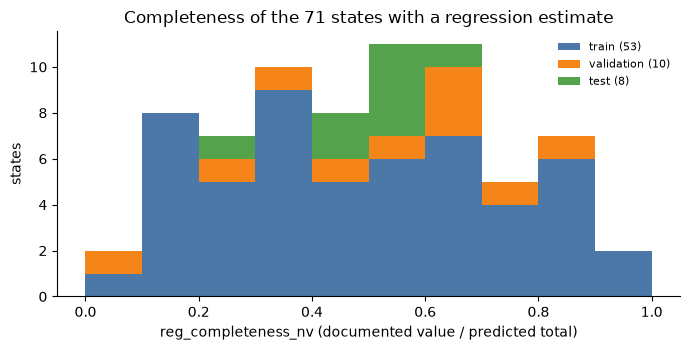

In [10]:
colours = {"train": "#4C78A8", "validation": "#F58518", "test": "#54A24B"}
fig, ax = plt.subplots(figsize=(7, 3.6))
bins = np.linspace(0, 1, 11)
parts = [final_model_state.loc[a.values & (final_model_state_split == s), "reg_completeness_nv"] for s in ["train", "validation", "test"]]
ax.hist(parts, bins=bins, stacked=True, color=[colours[s] for s in ["train", "validation", "test"]],
        label=[f"{s} ({len(p)})" for s, p in zip(["train", "validation", "test"], parts)])
ax.set_xlabel("reg_completeness_nv (documented value / predicted total)")
ax.set_ylabel("states")
ax.set_title("Completeness of the 71 states with a regression estimate")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## Summary of the merge and what was checked (numbers from the run above)

- **Saved:** `data/processed/classification/model_state_with_reg.csv` is `model_state.csv` (60 original columns, unchanged, re-read and compared) plus 5 new columns, which gives **431 rows and 65 columns**. The diagnostics (431 rows and 17 columns, not a model input) are in `data/interim/regression/regression_state_diagnostics.csv`. The classification team's `model_state.csv` was not modified.
- **The documented value extraction matches the classification team:** Summing `Current_Estimated_Value` of the assets with `Created_At <= Prediction_Time` reproduces their `documented_asset_count` and `documented_value_total` for 431 of 431 states. After splitting the same assets, `documented_value_nv` plus the recorded vehicle value equals `documented_value_total` in all 431 states, and **6 states** already have a vehicle documented (there `documented_value_nv` is lower than their total).
- **Only 71 of the 431 states (16.5%) have a regression estimate** (`reg_available = 1`, which needs at least 10 non-vehicle items with a value). The other 360 states are padded with -1 and have `documented_value_nv` only. By split, **train has 53 of 309 states, validation 10 of 67 and test 8 of 55**. By checkpoint, 46 states use the basket of 10, 9 use 20, 13 use 30 and 3 use 50 (train 33, 6, 12 and 2, validation 7, 2, 1 and 0, test 6, 1, 0 and 1). Any conclusion on validation (10 states) or test (8 states) will therefore rest on very few rows.
- **Baskets and rule checks:** Every basket is the earliest N items of the checkpoint, and no basket contains an item documented after its state (asserted for all 71 states). The cut never splits items with the same timestamp. States of the same home and checkpoint have the same `reg_pred_total_nv`. For example, PRP-000065 has 110,600.39 at both 10 and 11 documented items, while `reg_pred_gap_nv` falls from 58,385 to 33,885 and `reg_completeness_nv` rises from 0.47 to 0.69. PRP-000588 changes from the basket of 10 to the basket of 20 at 21 documented items, and its prediction moves from 43,378 to 54,854.
- **Vehicles:** PRP-000215 has a documented vehicle of $45,000, so its `documented_value_total` is 55,048 but its `documented_value_nv` is 10,048 and its `reg_completeness_nv` is 0.31. Using the total with vehicles instead would give a negative gap and a completeness above 1.
- **Values of the 71 estimates:** `reg_pred_total_nv` has a median of $37,437 (mean $48,462, range $18,411 to $130,704), `reg_pred_gap_nv` has a median of $18,512, and `reg_completeness_nv` has a median of 0.53 (mean 0.50, range 0.03 to 0.99). **No prediction had to be raised to the documented value**, because the clip changed 0 of 71.
- **Model check:** The two saved models reproduce all 230 validation predictions stored in `regression_predictions_all_splits.csv`, and every one of the 1,840 blended predictions in that file uses the 0.28 and 0.72 weight. This is a consistency check only and no error was calculated. The csv cannot be joined to the states, because it has no `Prediction_Time` and its baskets are random draws that contain items documented after the state time, so the features come from the saved models applied to the earliest-N basket of each state.
- **Caveat to keep in the report:** The regression models were fitted on the train homes with the full household total as label, so the **53 train states' predictions are in-sample** (flag `pred_is_in_sample` in the diagnostics) and may be a little more accurate than those of validation and test states, which are out-of-sample (10 and 8 states). No out-of-fold step was done on purpose, because this notebook only merges the model as features.
- **Not done here:** The new columns have not been tested in the classification model, and nothing was scored in this notebook. The regression columns can be dropped with `startswith("reg_")` if the classifier should run without them.